In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [50]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']


In [51]:
label_names=emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [52]:
df_train=pd.DataFrame(
    {
        "text":train_text,
        "label":[label_names[i] for i in train_label]
    }
)
df_test=pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)

In [53]:
df_train.isnull().sum()

,0
text,0
label,0


In [54]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

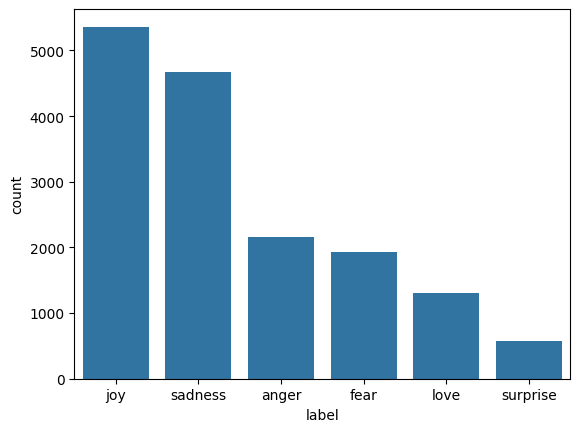

In [55]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [56]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [57]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000

tokenizer=Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train["text"])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequences=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_label=np.array(train_label)
test_label=np.array(test_label)

num_classes=len(np.unique(train_label))
num_classes

print(f"vocabulary size {len(tokenizer.word_index)}")
print(f"max sentence length{padded_train_sequences.shape[1]}")



vocabulary size 15213
max sentence length50


In [58]:
from sklearn.utils import class_weight
class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label),
    y=train_label
)

class_weights_dict=dict(enumerate(class_weights))

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,GRU,Dense,Dropout,SimpleRNN

rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
rnn_model.fit(
    padded_train_sequences,
    train_label,
    validation_data=(padded_test_sequences,test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
rnn_loss,rnn_accuracy=rnn_model.evaluate(padded_test_sequences,test_label)
print(f"rnn loss {rnn_loss}")
print(f"rnn accuracy {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1661 - loss: 1.9214 - val_accuracy: 0.1685 - val_loss: 1.7849
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1629 - loss: 1.8045 - val_accuracy: 0.0820 - val_loss: 1.8156
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1669 - loss: 1.7880 - val_accuracy: 0.1555 - val_loss: 1.7928
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1554 - loss: 1.7725 - val_accuracy: 0.1135 - val_loss: 1.7925
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1685 - loss: 1.7849
rnn loss 1.7849233150482178
rnn accuracy 0.16850000619888306


In [62]:
lstm_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.fit(
    padded_train_sequences,
    train_label,
    validation_data=(padded_test_sequences,test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
lstm_loss,lstm_accuracy=lstm_model.evaluate(padded_test_sequences,test_label)
print(f"lstm loss {lstm_loss}")
print(f"lstm accuracy {lstm_accuracy}")




Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1556 - loss: 1.7949 - val_accuracy: 0.1155 - val_loss: 1.7857
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1402 - loss: 1.7933 - val_accuracy: 0.2395 - val_loss: 1.7859
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1402 - loss: 1.7919 - val_accuracy: 0.1235 - val_loss: 1.8110
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1155 - loss: 1.7857
lstm loss 1.78573477268219
lstm accuracy 0.11550000309944153


In [63]:
gru_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_model.fit(
    padded_train_sequences,
    train_label,
    validation_data=(padded_test_sequences,test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
gru_loss,gru_accuracy=gru_model.evaluate(padded_test_sequences,test_label)
print(f"gru loss {gru_loss}")
print(f"gru accuacry {gru_accuracy}")

#just for comparison
result_df=pd.DataFrame(
    {
        'model':['rnn','lstm','gru'],
        'test loss':[rnn_loss,lstm_loss,gru_loss],
        'test accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
    }
).sort_values(by="test accuracy",ascending=False)
result_df

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1382 - loss: 1.7970 - val_accuracy: 0.1375 - val_loss: 1.7789
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1558 - loss: 1.7947 - val_accuracy: 0.1355 - val_loss: 1.8068
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1541 - loss: 1.7946 - val_accuracy: 0.0365 - val_loss: 1.8001
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1594 - loss: 1.7937 - val_accuracy: 0.0450 - val_loss: 1.7961
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1375 - loss: 1.7789
gru loss 1.7788676023483276
gru accuacry 0.13750000298023224


,model,test loss,test accuracy
0,rnn,1.784923,0.1685
2,gru,1.778868,0.1375
1,lstm,1.785735,0.1155


In [64]:
from tensorflow.keras.layers import Bidirectional
BiGRU=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
BiGRU.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
BiGRU.fit(
    padded_train_sequences,
    train_label,
    validation_data=(padded_test_sequences,test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
BiGRU_loss,BiGRU_accuracy=BiGRU.evaluate(padded_test_sequences,test_label)
print(f"BiGRU loss {BiGRU_loss}")
print(f"BiGRU accuracy {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4685 - loss: 1.1866 - val_accuracy: 0.8705 - val_loss: 0.4629
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9074 - loss: 0.2793 - val_accuracy: 0.9015 - val_loss: 0.2931
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9351 - loss: 0.1702 - val_accuracy: 0.9210 - val_loss: 0.2077
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9574 - loss: 0.1131 - val_accuracy: 0.9175 - val_loss: 0.2383
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9653 - loss: 0.0977 - val_accuracy: 0.9220 - val_loss: 0.2296
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9728 - loss: 0.0783 - val_accuracy: 0.9125 - val_loss: 0.3395
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9210 - loss: 0.2077
BiGRU loss 0.2077239602804184
BiGRU accuracy 0.9210000038146973


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


<Axes: >

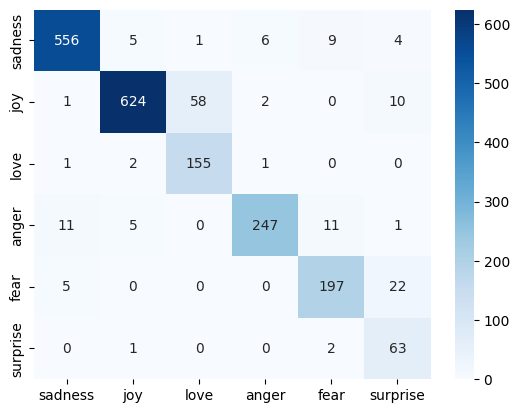

In [66]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions=np.argmax(BiGRU.predict(padded_test_sequences),axis=1)

sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)


In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences=tokenizer.texts_to_sequences(sample_texts)
padded_sample_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post',truncating='post')

sample_predictions=np.argmax(BiGRU.predict(padded_sample_sequences),axis=1)

for i in range(len(sample_texts)):
  print(f"text:{sample_texts[i]}\n the predicted emotion is {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
text:I can't believe how happy I am right now, this is amazing!
 the predicted emotion is surprise
text:I feel so alone and hopeless today.
 the predicted emotion is sadness
text:I am furious that they cancelled the trip at the last minute.
 the predicted emotion is anger
text:I feel terrified when walking down dark alleyways alone.
 the predicted emotion is fear
text:I was shocked and completely surprised by the unexpected gift!
 the predicted emotion is surprise


In [68]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True)

BiGRU.save(os.path.join(model_dir,'BiGRU_model.keras'))

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer,file)